# Data preparation

In [ ]:
# loading data
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
import numpy as np

# setting theme for vis
sns.set_theme(style="darkgrid")

In [ ]:
# creating data frame and selecting columns for analysis
data = pd.read_csv('data.csv', sep = ';', index_col=0, parse_dates=True)#, decimal = ",", encoding='cp1252')
col_of_interest = ['GDP at market prices', 'Exports','Consumption: Private consumption', 'Consumption: Public consumption', 'Total fixed investments', 'Imports']
df = data[col_of_interest].copy()
df.head()

,GDP at market prices,Exports,Consumption: Private consumption,Consumption: Public consumption,Total fixed investments,Imports
Year,,,,,,
1950-01-01,5061.770670,454.862029,3532.350088,572.059746,1044.822946,516.398468
1951-01-01,6011.069737,659.065626,4185.629525,677.074995,1234.066578,758.917403
1952-01-01,6505.266311,607.280157,4515.465538,755.192616,1416.788025,821.850569
1953-01-01,7227.473291,703.795264,4934.367869,802.805018,1624.436576,867.891782
1954-01-01,7727.142426,760.012851,5108.907617,909.119879,1799.027022,858.758256


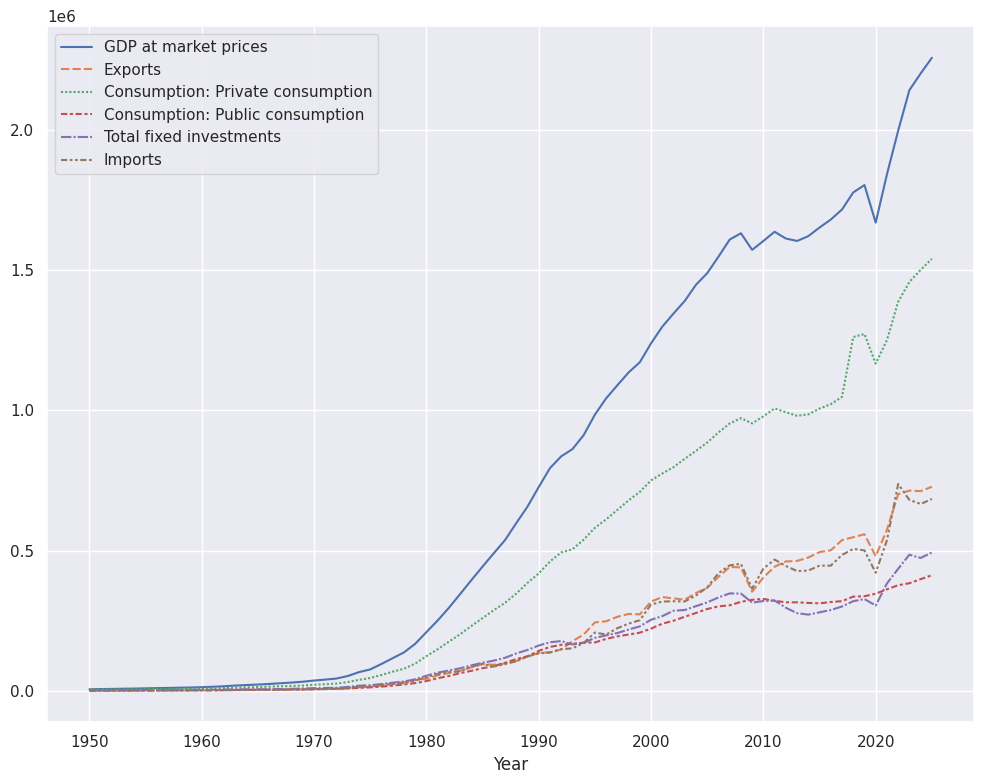

In [ ]:
# plotting all serieses on one plot
fig, ax = plt.subplots( figsize=(10, 8))
sns.lineplot(data=df, ax = ax)
plt.tight_layout()
plt.show()

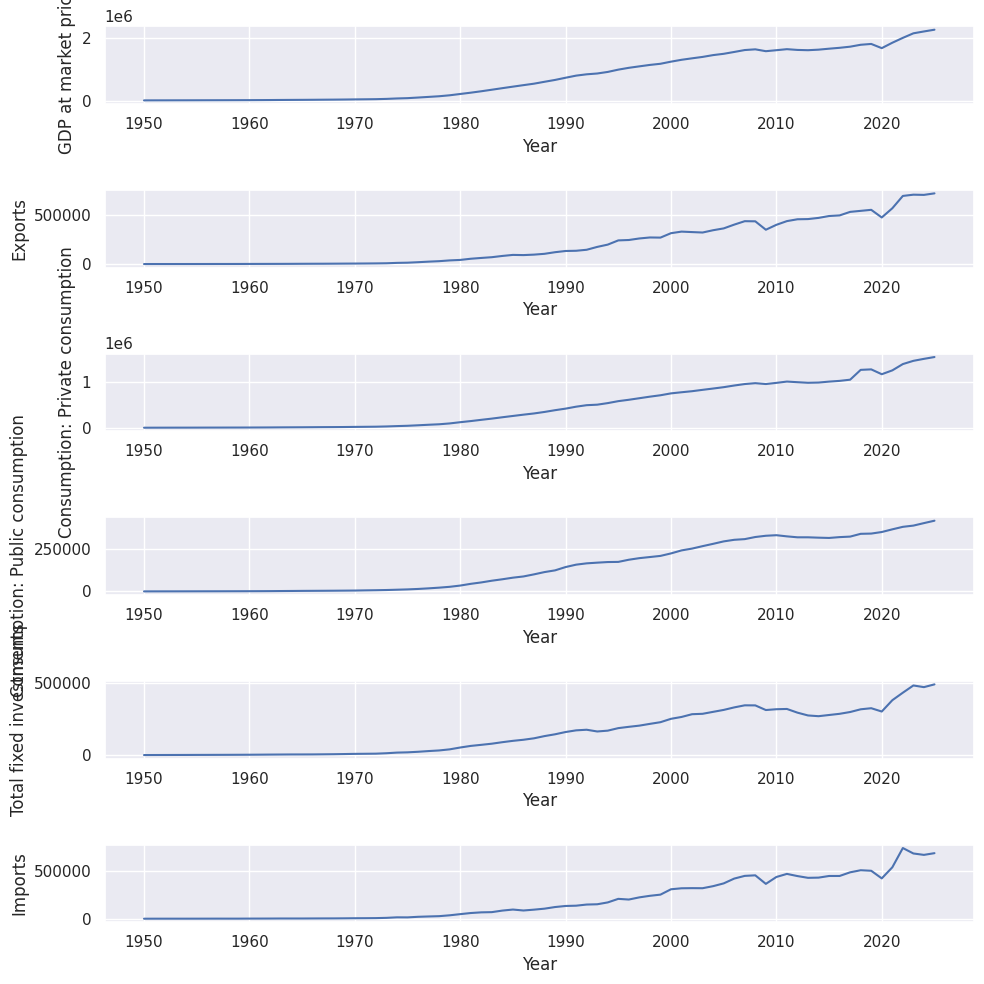

In [ ]:
# plot all series on separate plot
fig, ax = plt.subplots(nrows=len(col_of_interest), figsize=(10, 10))
for col in col_of_interest:
  sns.lineplot(data=df, y=col, x="Year", ax = ax[int(col_of_interest.index(col))])
plt.tight_layout()
plt.show()

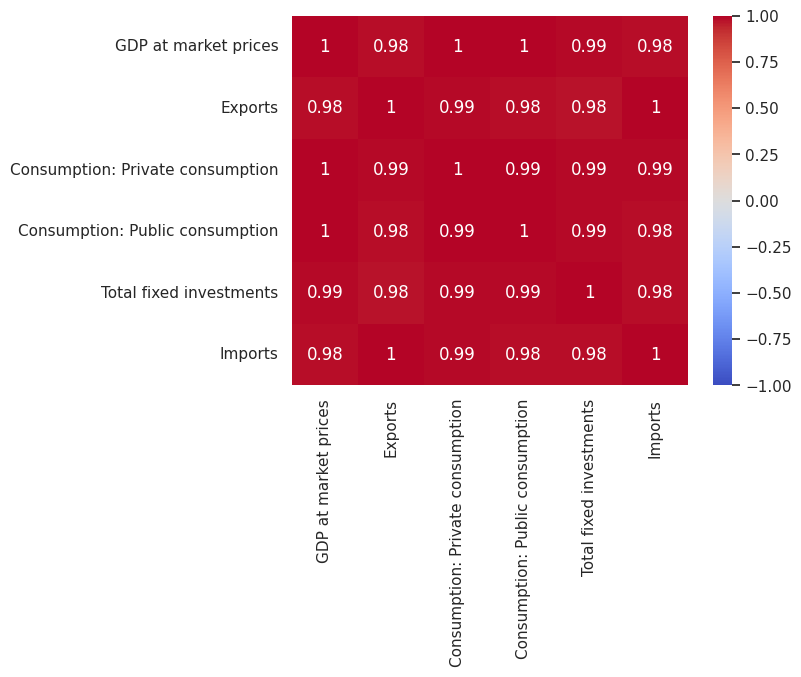

In [ ]:
# correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

**High correlation -> common trend (population grow). Try again after differencing.**

In [ ]:
# check outliers
for col in col_of_interest:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"Outliers in col {col}:")
  print(len(outliers))

Outliers in col GDP at market prices:
0
Outliers in col Exports:
0
Outliers in col Consumption: Private consumption:
0
Outliers in col Consumption: Public consumption:
0
Outliers in col Total fixed investments:
0
Outliers in col Imports:
0


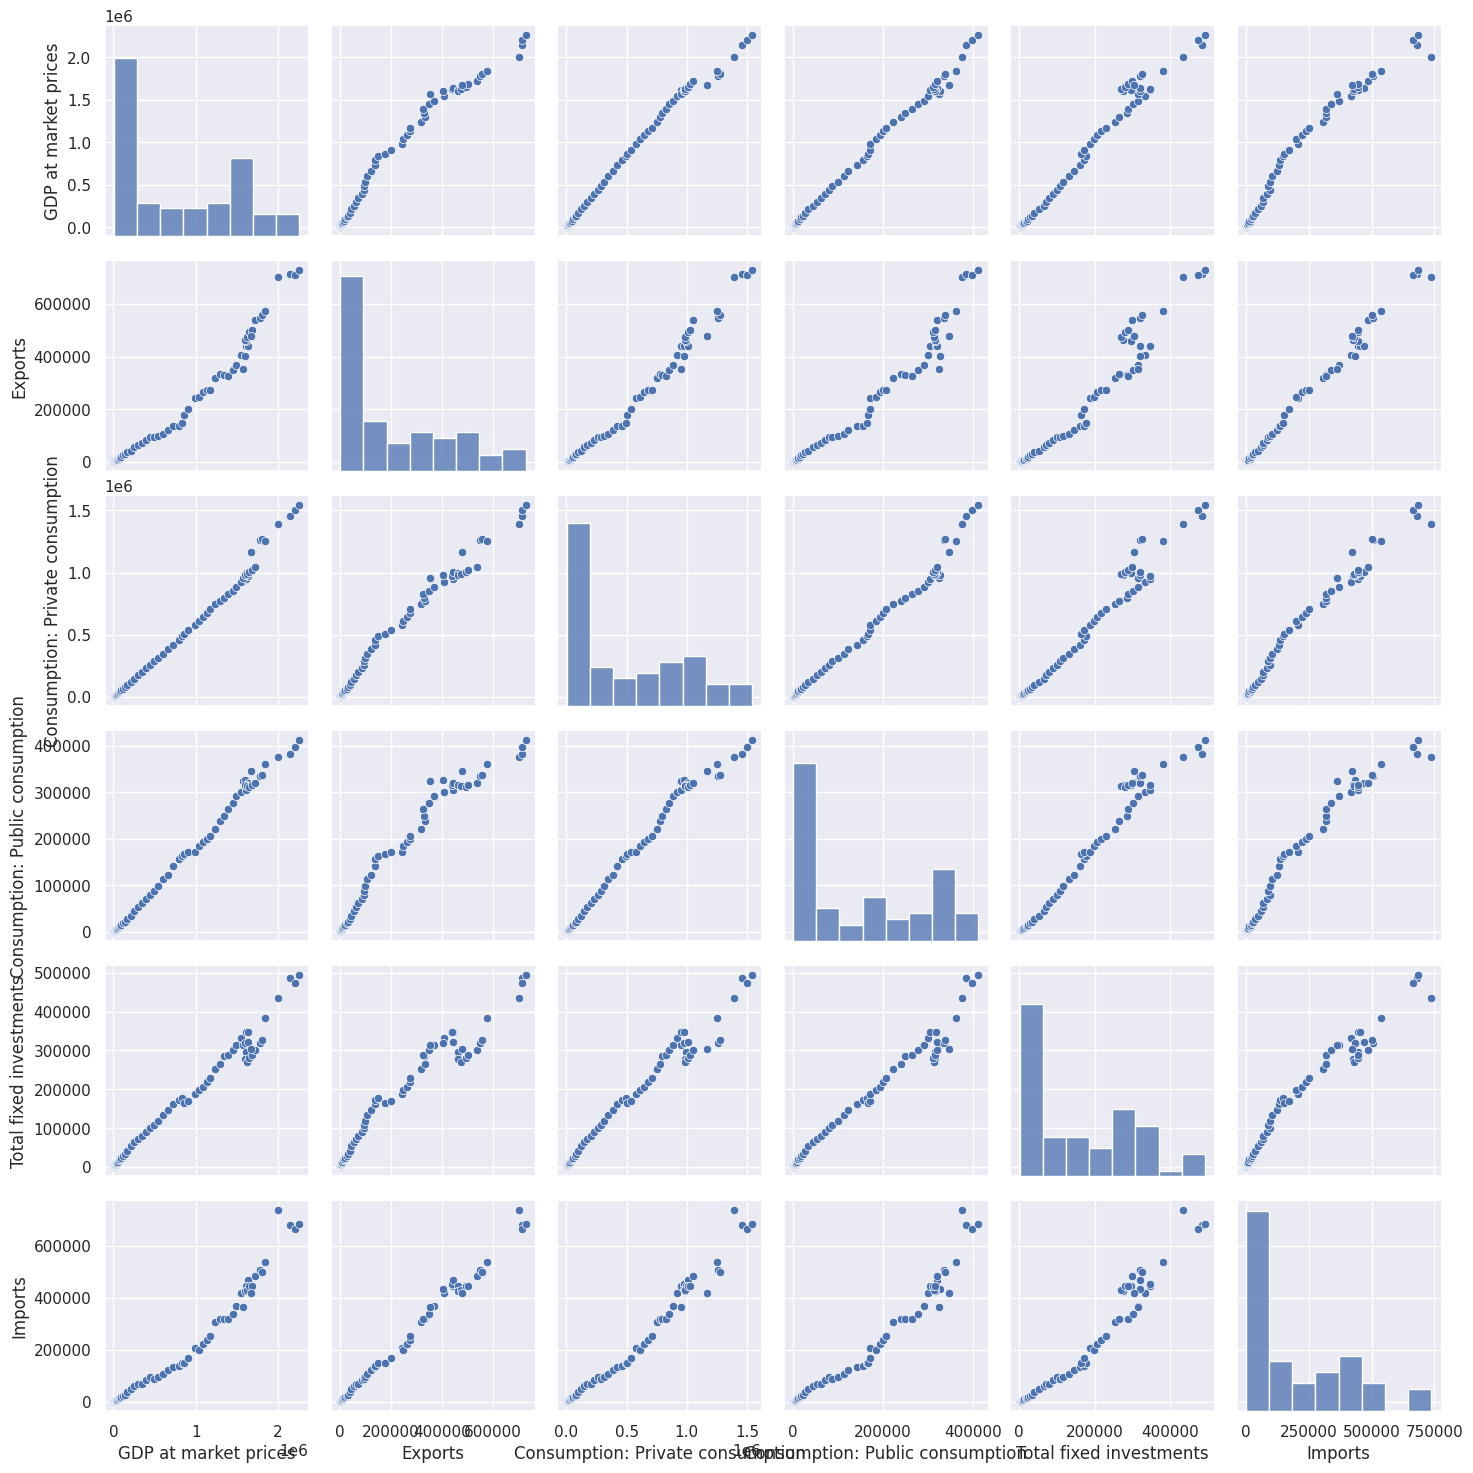

In [ ]:
# plot pairplot
sns.pairplot(df)
plt.show()

# Stationarity

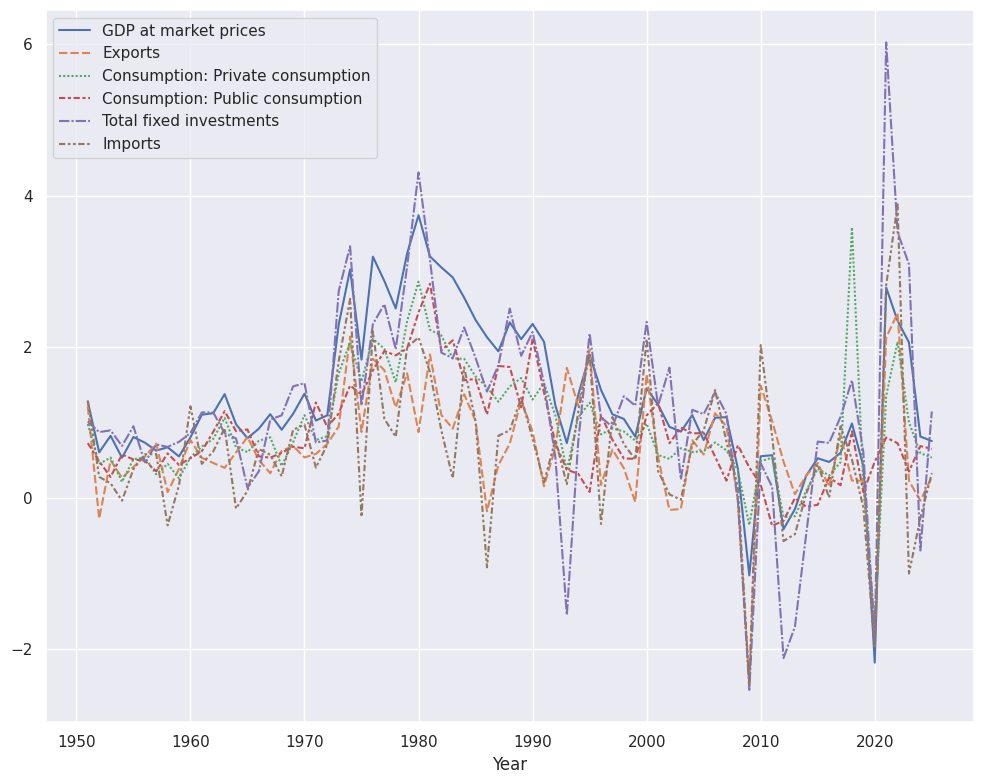

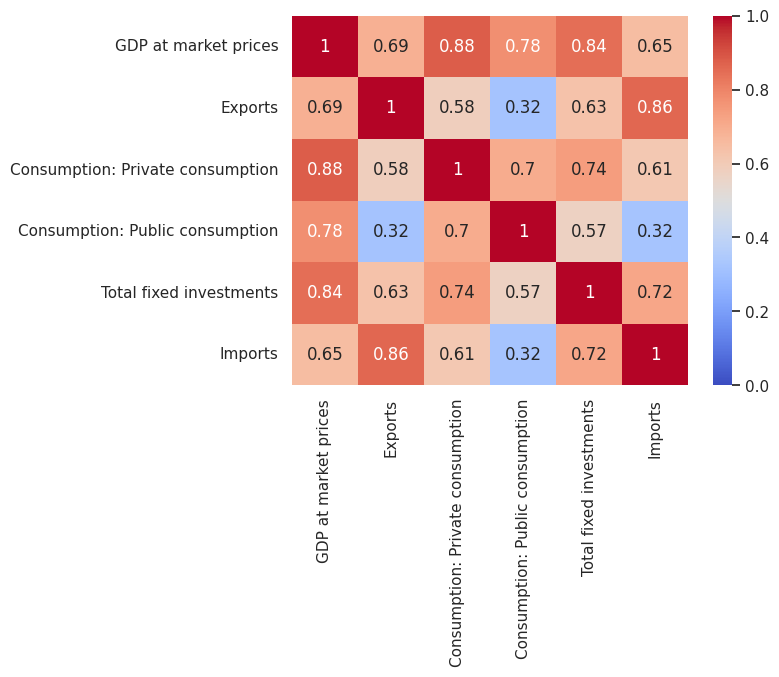

In [ ]:
# stabilase variance (box cox)
df_trans = df.copy()
lambdas = {}

for col in col_of_interest:
    df_trans[col], lam = boxcox(df[col])
    lambdas[col] = lam

# delete trend (difference)
df_diff = df_trans.diff().dropna()

# plotting new serieses on one plot
fig, ax = plt.subplots( figsize=(10, 8))
sns.lineplot(data=df_diff, ax = ax)
plt.tight_layout()
plt.show()

# correlation matrix
corr = df_diff.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.show()

## Check the staionarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test and print results
def adf_test(series, series_name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- {series_name} ---')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical values: {result[4]}')
    if result[1] <= 0.05:
        print('=> Stationary (reject H0)')
    else:
        print('=> Non-stationary (fail to reject H0)')
    print('')

# Apply to all numeric columns (skip the Year column which is index)
for col in df_diff.columns:
    adf_test(df_diff[col], col)

--- GDP at market prices ---
ADF Statistic: -2.161435
p-value: 0.220539
Critical values: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
=> Non-stationary (fail to reject H0)

--- Exports ---
ADF Statistic: -1.421249
p-value: 0.572048
Critical values: {'1%': np.float64(-3.53692771987915), '5%': np.float64(-2.907887369384766), '10%': np.float64(-2.591493291015625)}
=> Non-stationary (fail to reject H0)

--- Consumption: Private consumption ---
ADF Statistic: -2.094404
p-value: 0.246771
Critical values: {'1%': np.float64(-3.540522678829176), '5%': np.float64(-2.9094272025108254), '10%': np.float64(-2.5923136524453696)}
=> Non-stationary (fail to reject H0)

--- Consumption: Public consumption ---
ADF Statistic: -1.970791
p-value: 0.299525
Critical values: {'1%': np.float64(-3.5232835753964475), '5%': np.float64(-2.902030597326081), '10%': np.float64(-2.5883710883843123)}
=> Non-stationary (fail to reject H0)

--- Total

Almost all of the serieses are non-stationary. Do differencing twice.

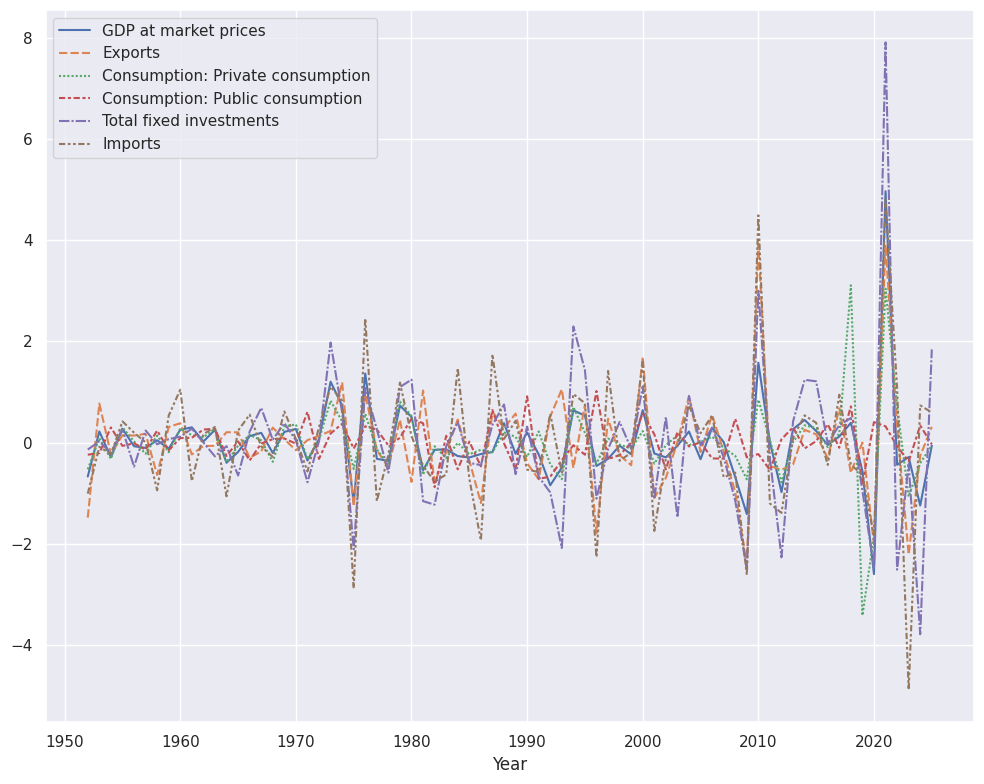

--- GDP at market prices ---
ADF Statistic: -7.932235
p-value: 0.000000
Critical values: {'1%': np.float64(-3.526004646825607), '5%': np.float64(-2.9032002348069774), '10%': np.float64(-2.5889948363419957)}
=> Stationary (reject H0)

--- Exports ---
ADF Statistic: -4.237918
p-value: 0.000568
Critical values: {'1%': np.float64(-3.53692771987915), '5%': np.float64(-2.907887369384766), '10%': np.float64(-2.591493291015625)}
=> Stationary (reject H0)

--- Consumption: Private consumption ---
ADF Statistic: -7.261708
p-value: 0.000000
Critical values: {'1%': np.float64(-3.5274258688046647), '5%': np.float64(-2.903810816326531), '10%': np.float64(-2.5893204081632653)}
=> Stationary (reject H0)

--- Consumption: Public consumption ---
ADF Statistic: -11.327384
p-value: 0.000000
Critical values: {'1%': np.float64(-3.5232835753964475), '5%': np.float64(-2.902030597326081), '10%': np.float64(-2.5883710883843123)}
=> Stationary (reject H0)

--- Total fixed investments ---
ADF Statistic: -2.299647

In [ ]:
data_diff_2 = df_diff.diff().dropna()

# plotting new serieses on one plot
fig, ax = plt.subplots( figsize=(10, 8))
sns.lineplot(data=data_diff_2, ax = ax)
plt.tight_layout()
plt.show()

# Apply to all numeric columns (skip the Year column which is index)
for col in data_diff_2.columns:
    adf_test(data_diff_2[col], col)

In [ ]:
train_end = '2012-01-01'
test_start = '2013-01-01'

train = data_diff_2.loc[:train_end].copy()
test  = data_diff_2.loc[test_start:].copy()

print(f"\nTrain size: {len(train)} observations")
print(f"Test size : {len(test)} observations")


Train size: 61 observations
Test size : 13 observations


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
# Example: test if Exports Granger-causes GDP (on stationary series)
data_stationary = data_diff_2[['GDP at market prices', 'Exports']].diff().dropna()
gc_res = grangercausalitytests(data_stationary, maxlag=4, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0261  , p=0.8722  , df_denom=69, df_num=1
ssr based chi2 test:   chi2=0.0272  , p=0.8690  , df=1
likelihood ratio test: chi2=0.0272  , p=0.8690  , df=1
parameter F test:         F=0.0261  , p=0.8722  , df_denom=69, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.4193  , p=0.2492  , df_denom=66, df_num=2
ssr based chi2 test:   chi2=3.0537  , p=0.2172  , df=2
likelihood ratio test: chi2=2.9899  , p=0.2243  , df=2
parameter F test:         F=1.4193  , p=0.2492  , df_denom=66, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.1801  , p=0.3245  , df_denom=63, df_num=3
ssr based chi2 test:   chi2=3.9337  , p=0.2687  , df=3
likelihood ratio test: chi2=3.8271  , p=0.2807  , df=3
parameter F test:         F=1.1801  , p=0.3245  , df_denom=63, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.9493  , p=0.4420  , df_d

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


# Models

## VAR

In [ ]:
# Fit VAR
from statsmodels.tsa.api import VAR
from scipy.special import inv_boxcox

model = VAR(train)
lag_order = model.select_order(maxlags=4).aic  # pick min AIC
print(f"\nSelected lag order (AIC): {lag_order}")

results = model.fit(lag_order)
print("\nWhiteness test (should have p > 0.05):")
print(results.test_whiteness())  # check residuals

# Forecast
steps = len(test)
last_obs = train.values[-lag_order:]
forecast_diff_2 = results.forecast(last_obs, steps=steps)

# Reverse second differencing -> get first differences
last_diff_1 = df_diff.loc[train_end]     # last value of first-differenced series (Box-Cox scale)
forecast_diff_1 = np.zeros_like(forecast_diff_2)
forecast_diff_1[0] = last_diff_1.values + forecast_diff_2[0]
for i in range(1, steps):
    forecast_diff_1[i] = forecast_diff_1[i-1] + forecast_diff_2[i]

# Reverse first differencing -> get Box-Cox levels
last_bc = df_trans.loc[train_end]           # last Box-Cox value before test period
forecast_bc = np.zeros_like(forecast_diff_1)
forecast_bc[0] = last_bc.values + forecast_diff_1[0]
for i in range(1, steps):
    forecast_bc[i] = forecast_bc[i-1] + forecast_diff_1[i]

# Inverse Box-Cox -> original scale
forecast_original = np.zeros_like(forecast_bc)
for i, col in enumerate(df.columns):
    forecast_original[:, i] = inv_boxcox(forecast_bc[:, i], lambdas[col])

# Create DataFrame for forecast
forecast_index = df.index[-steps:]   # same as test index
forecast_df = pd.DataFrame(forecast_original, index=forecast_index, columns=df.columns)
forecast_df


Selected lag order (AIC): 4

Whiteness test (should have p > 0.05):
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 259.052, critical value: 251.286>, p-value: 0.024>


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


,GDP at market prices,Exports,Consumption: Private consumption,Consumption: Public consumption,Total fixed investments,Imports
Year,,,,,,
2013-01-01,1.577286e+06,441961.252488,975903.240874,306536.176680,260212.081237,393047.939553
2014-01-01,1.549762e+06,415784.760152,964602.867836,295941.777419,244944.075793,371808.373374
2015-01-01,1.534942e+06,452479.744396,961833.222874,284298.932646,238741.186454,403907.781637
2016-01-01,1.521801e+06,476188.939954,961696.419234,272495.582980,225018.869465,407642.586315
2017-01-01,1.502365e+06,477508.233017,953353.791969,264614.873685,209837.653017,390159.217353
2018-01-01,1.464484e+06,451179.077489,934669.062014,260098.381527,192132.339969,361207.909397
2019-01-01,1.432660e+06,447592.632368,918867.843384,250053.841374,178863.817217,355214.304282
2020-01-01,1.412364e+06,468822.851105,912414.035906,237517.739782,168328.825588,362513.840393
2021-01-01,1.384324e+06,474985.970292,901392.332263,228634.624848,154629.891273,354924.127795


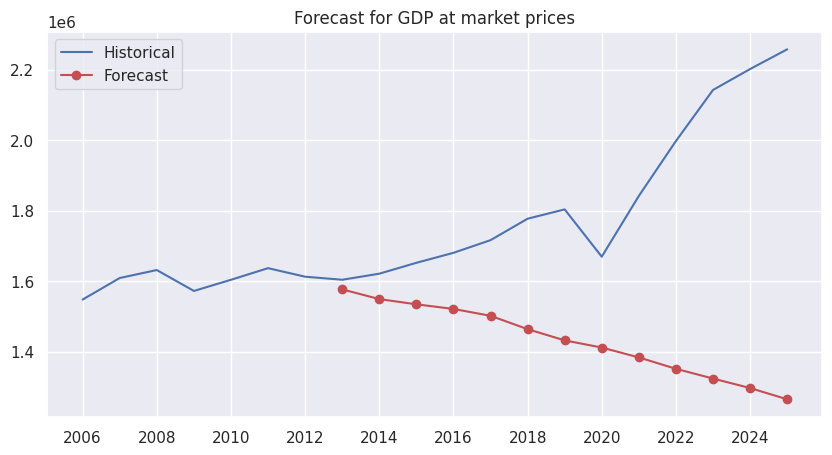

In [ ]:
var = 'GDP at market prices'
plt.figure(figsize=(10,5))
plt.plot(df[-20:].index, df[-20:][var], label='Historical')
plt.plot(forecast_df.index, forecast_df[var], 'ro-', label='Forecast')
plt.title(f'Forecast for {var}')
plt.legend()
plt.show()

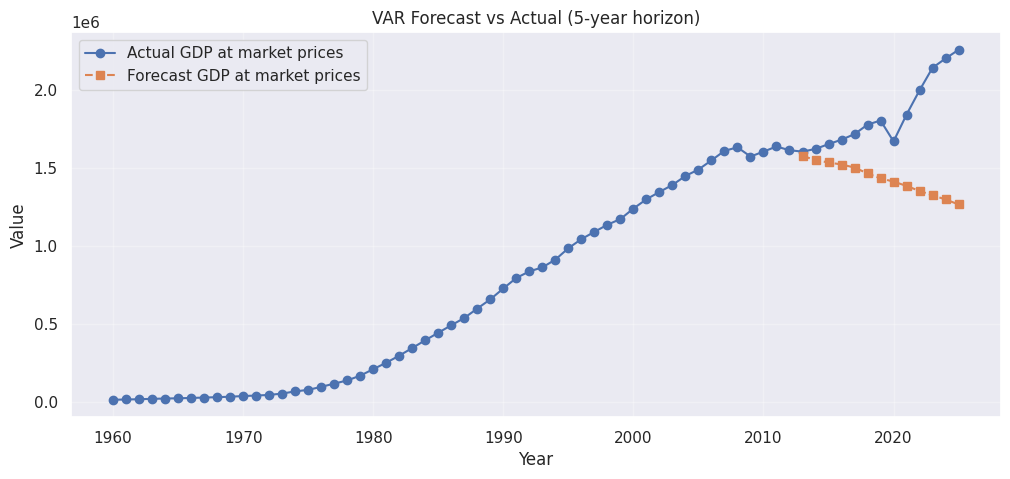

In [ ]:
plt.figure(figsize=(12, 5))
test = df[10:]
for var in df.columns[:1]:   # first three variables
    plt.plot(test.index, test[var], 'o-', label=f'Actual {var}')
    plt.plot(forecast_df.index, forecast_df[var], 's--', label=f'Forecast {var}')
plt.title('VAR Forecast vs Actual (5‑year horizon)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ARIMA

In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
gdp = df['GDP at market prices'].astype(float)
gdp_bc_vals, lam_gdp = boxcox(gdp)
gdp_bc = pd.Series(gdp_bc_vals, index=gdp.index, name='GDP_bc')

print(f"Lambda Box–Cox для GDP: {lam_gdp:.4f}")

gdp_bc_diff = gdp_bc.diff().dropna()

adf_test(gdp, 'GDP (уровень)')
adf_test(gdp_bc, 'GDP Box–Cox (уровень)')
adf_test(gdp_bc_diff, 'GDP Box–Cox (1-я разность)')

test_horizon = 10
train_diff = gdp_bc_diff.iloc[:-test_horizon]
test_diff = gdp_bc_diff.iloc[-test_horizon:]

Lambda Box–Cox для GDP: 0.2325
--- GDP (уровень) ---
ADF Statistic: 2.307499
p-value: 0.998960
Critical values: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
=> Non-stationary (fail to reject H0)

--- GDP Box–Cox (уровень) ---
ADF Statistic: -1.365491
p-value: 0.598704
Critical values: {'1%': np.float64(-3.526004646825607), '5%': np.float64(-2.9032002348069774), '10%': np.float64(-2.5889948363419957)}
=> Non-stationary (fail to reject H0)

--- GDP Box–Cox (1-я разность) ---
ADF Statistic: -2.161435
p-value: 0.220539
Critical values: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
=> Non-stationary (fail to reject H0)



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be use

Топ-5 моделей по AIC:
        order        aic         bic
11  (2, 0, 3)  93.235711  108.456421
12  (3, 0, 0)  96.013903  106.885840
13  (3, 0, 1)  97.895716  110.942040
7   (1, 0, 3)  98.349401  111.395724
14  (3, 0, 2)  99.495789  114.716500

Топ-5 моделей по BIC:
        order         aic         bic
12  (3, 0, 0)   96.013903  106.885840
11  (2, 0, 3)   93.235711  108.456421
4   (1, 0, 0)  102.072816  108.595978
5   (1, 0, 1)  100.858371  109.555921
13  (3, 0, 1)   97.895716  110.942040

Выбранный порядок (по AIC): (2, 0, 3)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                 GDP_bc   No. Observations:                   65
Model:                 ARIMA(2, 0, 3)   Log Likelihood                 -39.618
Date:                Tue, 09 Jun 2026   AIC                             93.236
Time:                        08:58:26   BIC                            108.456
Sample:                    01-01-1951   HQIC                            99.241
                         - 01-01-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4118      0.403      3.507      0.000       0.623       2.201
ar.L1          1.6197      0.191      8.498      0.000       1.246       1.993
ar.L2         -0.6948      0.207     -3.353      0.0

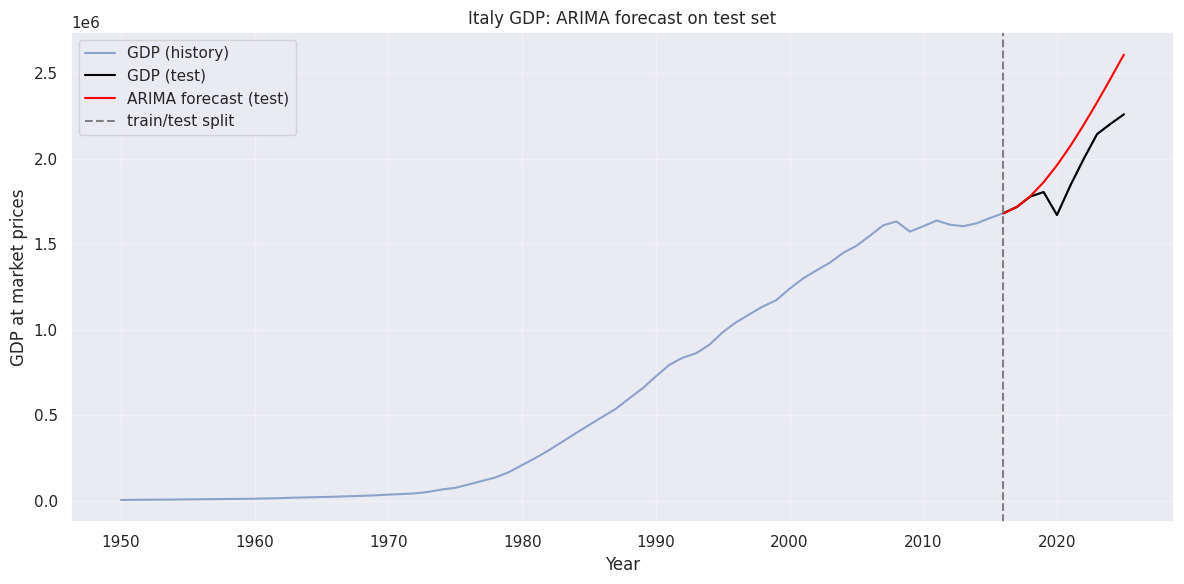

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramete

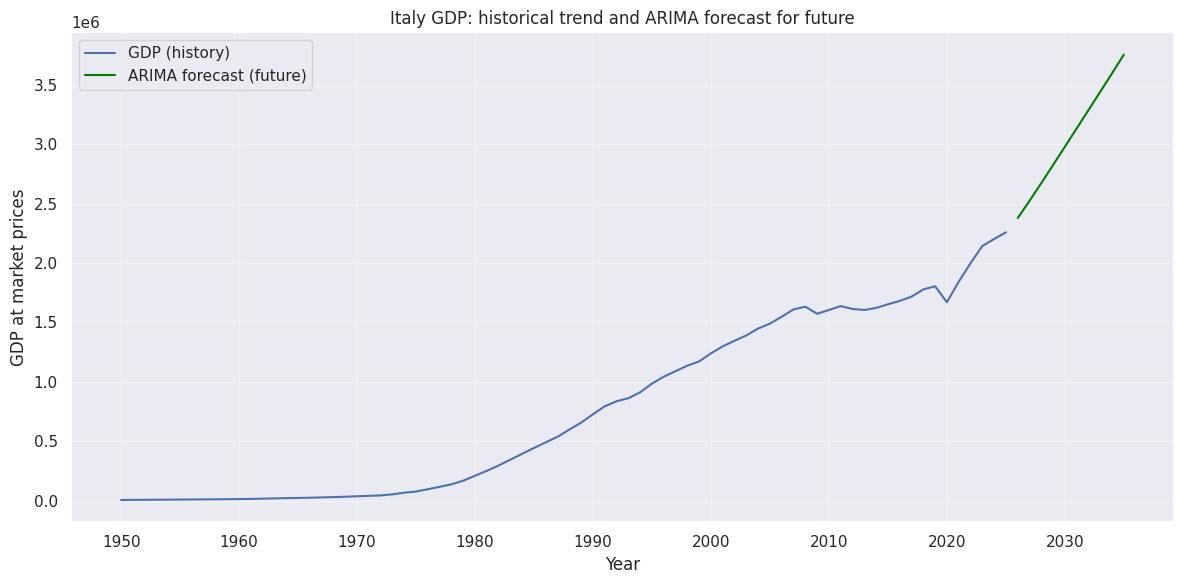

Forecast GDP for future:
2026-01-01    2.378037e+06
2027-01-01    2.522723e+06
2028-01-01    2.672679e+06
2029-01-01    2.825261e+06
2030-01-01    2.978921e+06
2031-01-01    3.132933e+06
2032-01-01    3.287153e+06
2033-01-01    3.441824e+06
2034-01-01    3.597418e+06
2035-01-01    3.754522e+06
Freq: YS-JAN, Name: GDP_forecast, dtype: float64


In [ ]:


p_range = range(0, 4)   # 0, 1, 2, 3
d_range = [0]
q_range = range(0, 4)   # 0, 1, 2, 3

results = []

for p, d, q in itertools.product(p_range, d_range, q_range):
    order = (p, d, q)
    try:
        model = ARIMA(train_diff, order=order)
        res = model.fit()
        results.append({
            'order': order,
            'aic': res.aic,
            'bic': res.bic
        })
    except Exception:
        continue

results_df = pd.DataFrame(results)

print("Топ-5 моделей по AIC:")
print(results_df.nsmallest(5, 'aic'))

print("\nТоп-5 моделей по BIC:")
print(results_df.nsmallest(5, 'bic'))

best_order_aic = tuple(results_df.nsmallest(1, 'aic').iloc[0]['order'])
print("\nВыбранный порядок (по AIC):", best_order_aic)

best_model = ARIMA(train_diff, order=best_order_aic)
best_fit = best_model.fit()
print(best_fit.summary())

forecast_res = best_fit.get_forecast(steps=len(test_diff))
pred_diff = forecast_res.predicted_mean


first_test_idx = test_diff.index[0]

pos = gdp_bc.index.get_loc(first_test_idx)
last_level_bc = gdp_bc.iloc[pos - 1]

pred_level_bc = last_level_bc + pred_diff.cumsum()
pred_level_bc = pd.Series(pred_level_bc, index=test_diff.index, name='GDP_bc_pred')

pred_level = inv_boxcox(pred_level_bc, lam_gdp)
pred_level = pd.Series(pred_level, index=test_diff.index, name='GDP_pred')

real_test = gdp.loc[test_diff.index]

mae = mean_absolute_error(real_test, pred_level)
rmse = mean_squared_error(real_test, pred_level)
print(f"MAE (тест):  {mae:,.2f}")
print(f"RMSE (тест): {rmse:,.2f}")

plt.figure(figsize=(12, 6))
plt.plot(gdp.index, gdp, label='GDP (history)', alpha=0.6)
plt.plot(real_test.index, real_test, label='GDP (test)', color='black')
plt.plot(pred_level.index, pred_level, label='ARIMA forecast (test)', color='red')
plt.axvline(real_test.index[0], color='grey', linestyle='--', label='train/test split')
plt.title('Italy GDP: ARIMA forecast on test set')
plt.xlabel('Year')
plt.ylabel('GDP at market prices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


steps_ahead = 10


full_fit = ARIMA(gdp_bc_diff, order=best_order_aic).fit()
future_diff = full_fit.get_forecast(steps=steps_ahead).predicted_mean

last_level_bc_full = gdp_bc.iloc[-1]
future_level_bc = last_level_bc_full + future_diff.cumsum()
future_level = inv_boxcox(future_level_bc, lam_gdp)


last_date = gdp.index[-1]
future_index = pd.date_range(start=last_date + pd.DateOffset(years=1),
                             periods=steps_ahead,
                             freq='YS')

future_series = pd.Series(future_level.values, index=future_index, name='GDP_forecast')


plt.figure(figsize=(12, 6))
plt.plot(gdp.index, gdp, label='GDP (history)')
plt.plot(future_series.index, future_series, label='ARIMA forecast (future)', color='green')
plt.title('Italy GDP: historical trend and ARIMA forecast for future')
plt.xlabel('Year')
plt.ylabel('GDP at market prices')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Forecast GDP for future:")
print(future_series)

# Drafts

In [ ]:
# loading data
from google.colab import files

uploaded = files.upload()

Saving data.csv to data (1).csv


In [ ]:
# inporting libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

In [ ]:
# creating data frame and selecting columns for analysis
data = pd.read_csv('data.csv', sep = ';', index_col=0, parse_dates=True)
col_of_interest = ['GDP at market prices', 'Exports','Private consumption', 'Public consumption', 'Total fixed investments', 'Imports']
data = data[col_of_interest]
data.head()

,Value added: agriculture,Value added: Industry including energy,Value added: industry Constructions,Value added:Total Industry,Value added: Services,Total Value Added,Net Indirect Taxes,GDP at market prices,Imports,Total supply,Exports,Consumption: Private consumption,Consumption: Public consumption,Total consumption,Constructions,Other fixed investments,Total fixed investments,Inventory variation,Total investments,Total uses
Year,,,,,,,,,,,,,,,,,,,,
1950-01-01,1296.767041,1271.910632,208.639829,1480.550461,1657.824952,4435.142453,626.628217,5061.770670,516.398468,5578.169138,454.862029,3532.350088,572.059746,4104.409835,352.859428,691.963517,1044.822946,-25.925671,1018.897275,5578.169138
1951-01-01,1358.430901,1605.697728,268.195353,1873.893081,2023.502943,5255.826925,755.242812,6011.069737,758.917403,6769.987140,659.065626,4185.629525,677.074995,4862.704520,459.994732,774.071846,1234.066578,14.150416,1248.216994,6769.987140
1952-01-01,1362.813727,1656.453823,328.809994,1985.263816,2311.461342,5659.538886,845.727425,6505.266311,821.850569,7327.116879,607.280157,4515.465538,755.192616,5270.658155,561.405599,855.382426,1416.788025,32.390542,1449.178567,7327.116879
1953-01-01,1557.056353,1773.860919,392.500673,2166.361592,2564.104348,6287.522294,939.950997,7227.473291,867.891782,8095.365073,703.795264,4934.367869,802.805018,5737.172887,678.861658,945.574918,1624.436576,29.960346,1654.396922,8095.365073
1954-01-01,1507.317232,1903.886489,453.842971,2357.729460,2796.942751,6661.989442,1065.152984,7727.142426,858.758256,8585.900682,760.012851,5108.907617,909.119879,6018.027496,794.021204,1005.005818,1799.027022,8.833312,1807.860335,8585.900682


In [ ]:
sns.set_theme(style="darkgrid")
col_of_interest = ['GDP at market prices', 'Exports','Private consumption', 'Public consumption', 'Total fixed investments', 'Imports']

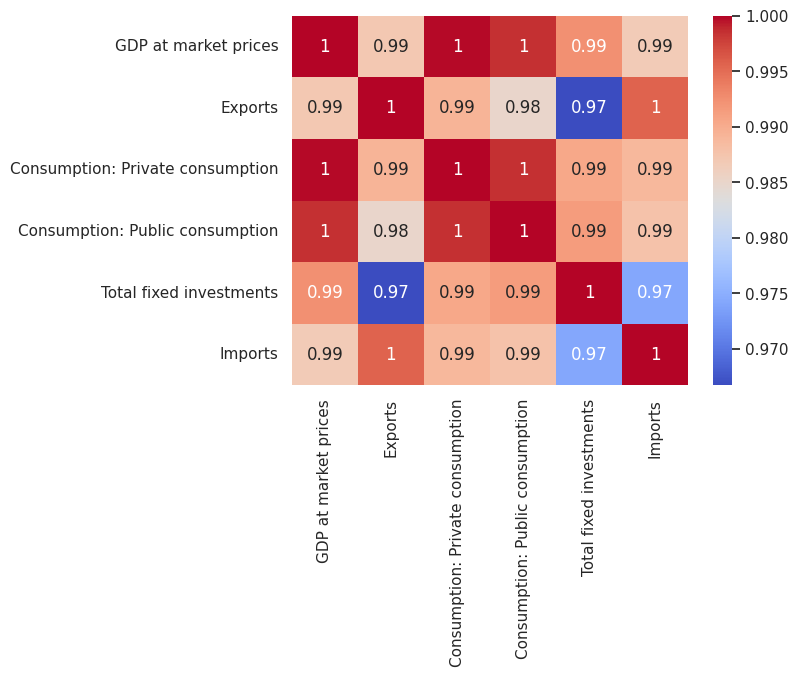

In [ ]:
df = pd.read_csv('data.csv', sep=';', index_col=0)
corr = df[['GDP at market prices', 'Exports', 'Consumption: Private consumption',
           'Consumption: Public consumption', 'Total fixed investments', 'Imports']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

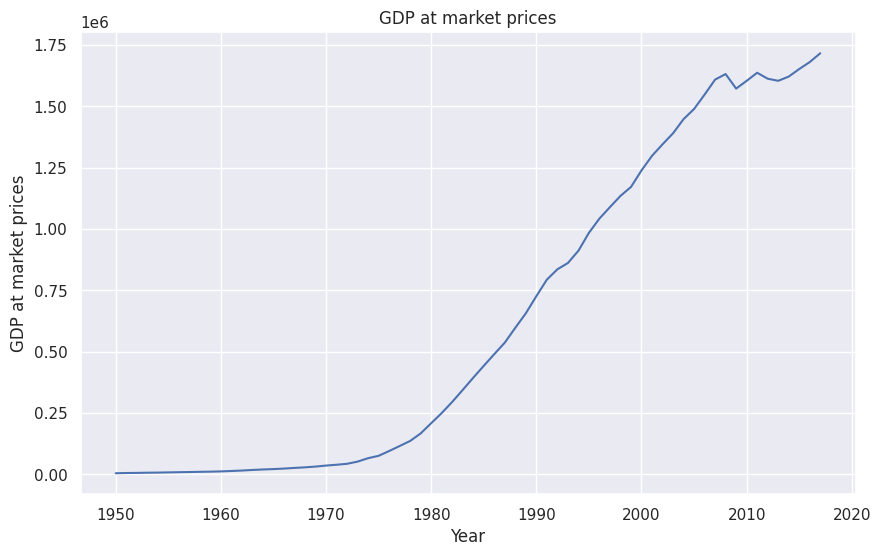

In [ ]:
plt.figure(figsize=(10, 6))

# Строим график общего тренда
sns.lineplot(data=data, y="GDP at market prices", x="Year")

plt.title("GDP at market prices")
plt.xlabel("Year")
plt.ylabel("GDP at market prices")
plt.show()

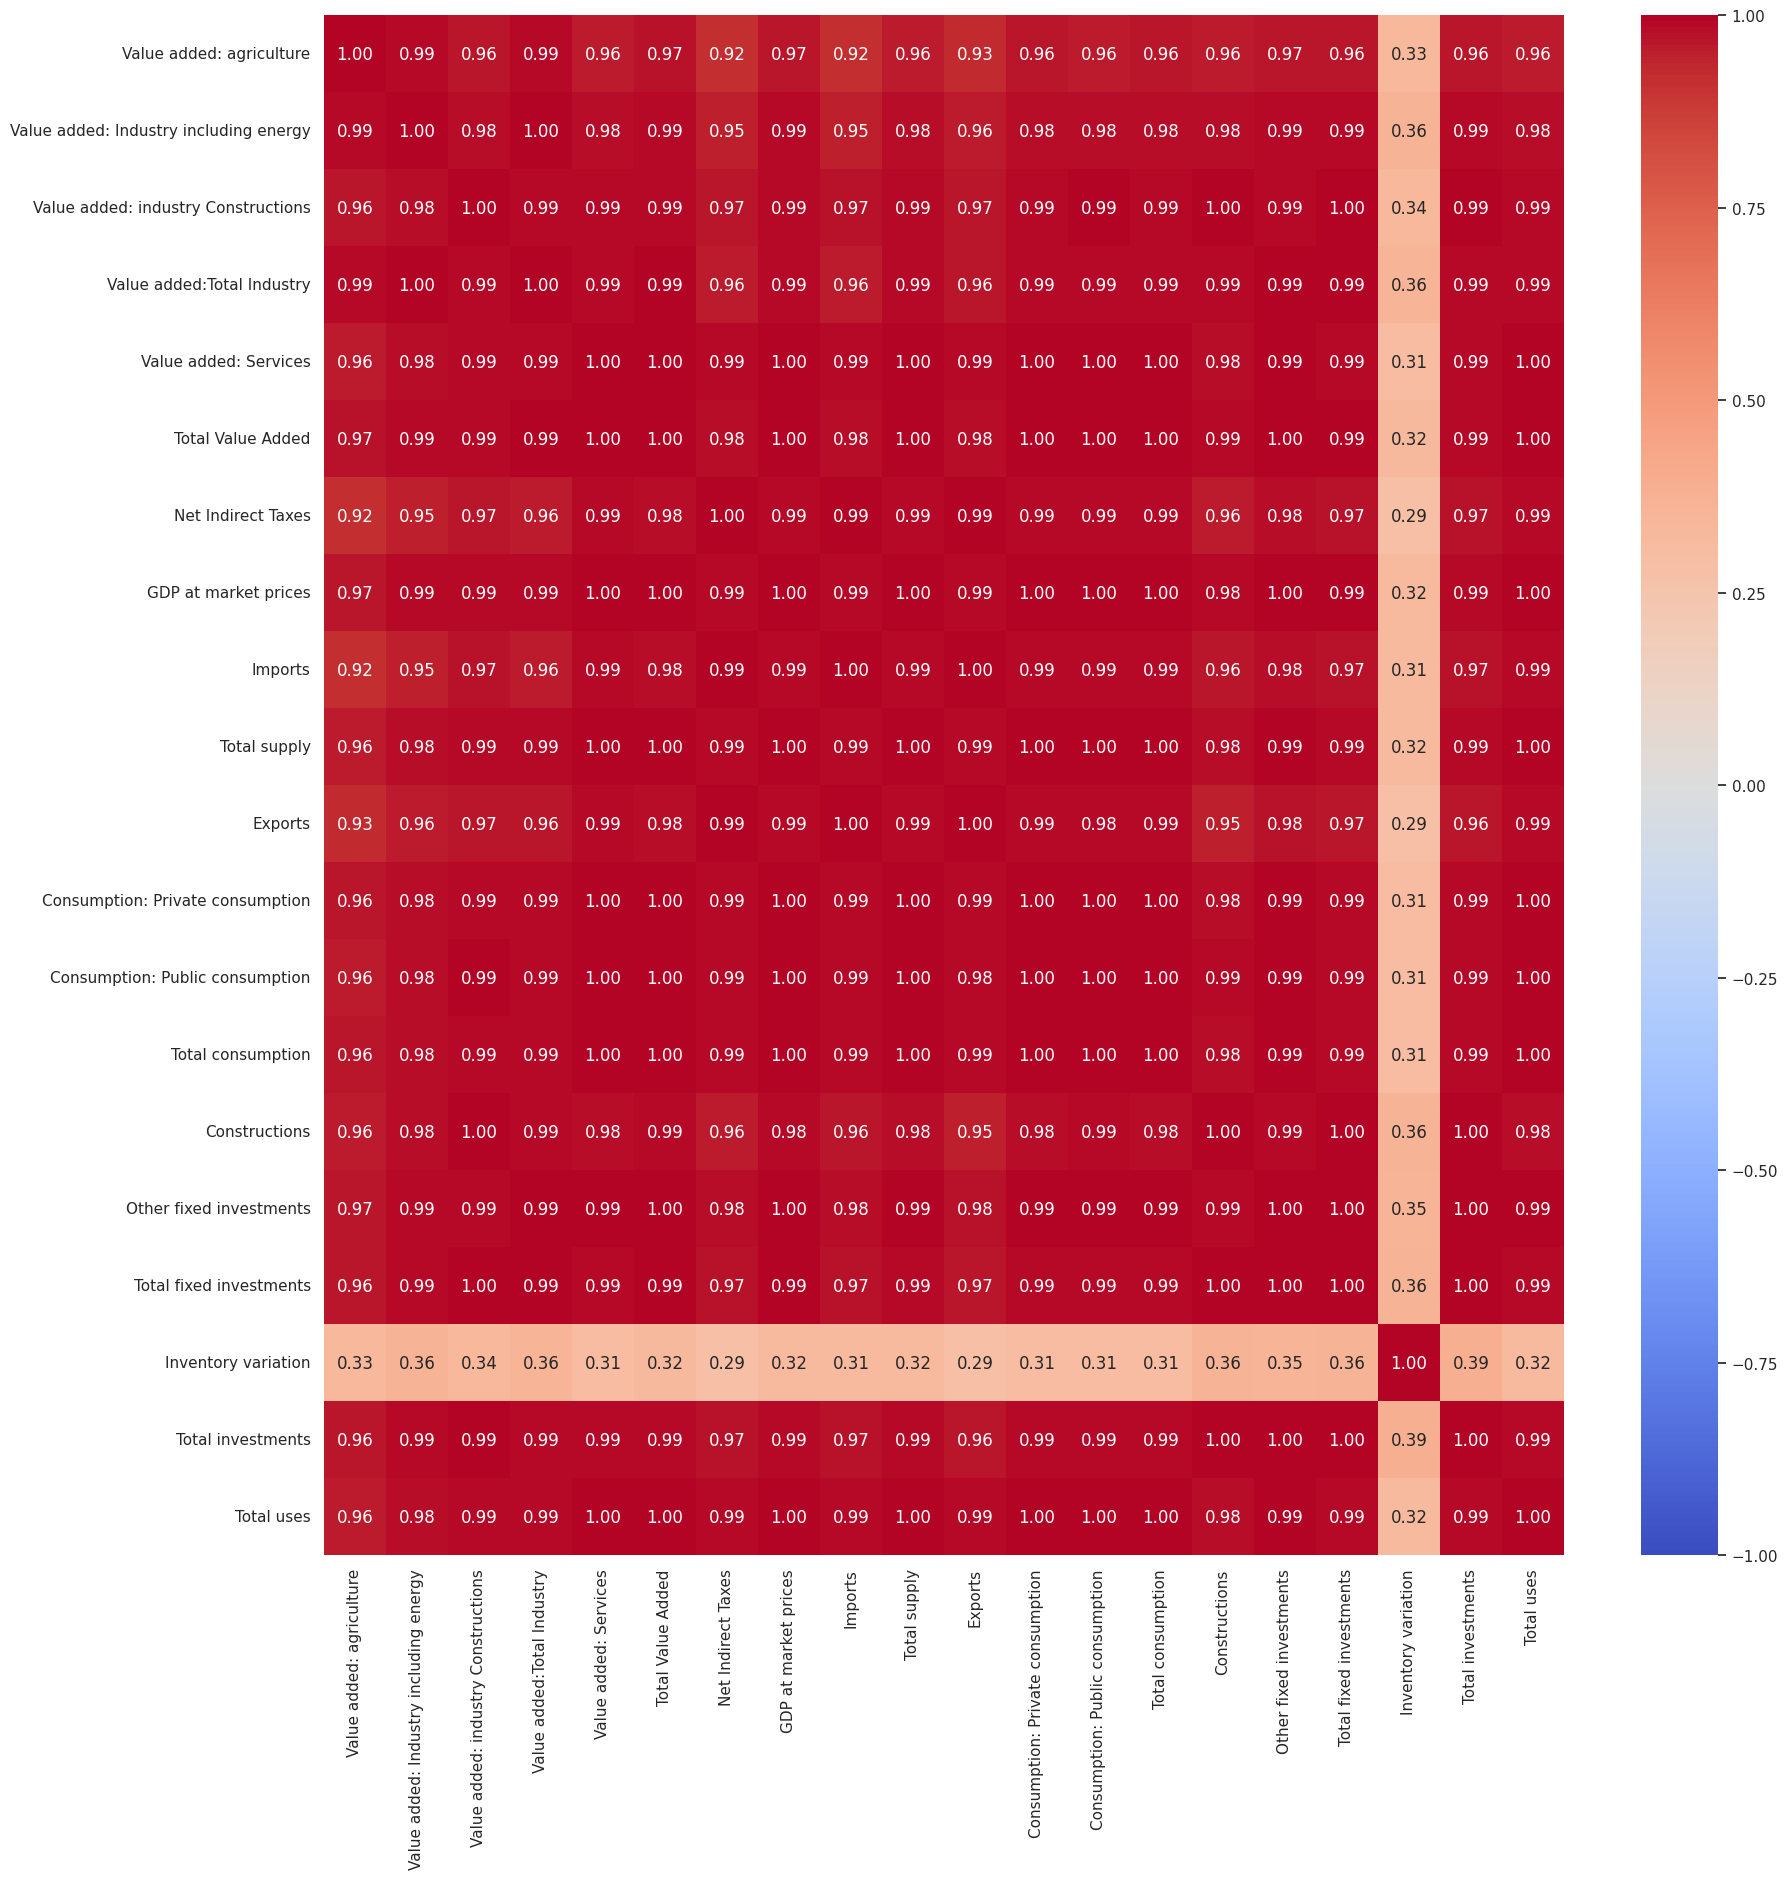

In [ ]:
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(20, 20))

sns.heatmap(
    corr_matrix,
    annot=True,     # Пишем значения внутри ячеек
    cmap='coolwarm', # Цветовая гамма (синий-белый-красный)
    fmt=".2f",      # Формат чисел (2 знака после запятой)
    vmin=-1, vmax=1 # Фиксируем границы цветов (от -1 до 1)
)


plt.show()

In [ ]:
print(data.shape)
train, test = data.iloc[:-20], data.iloc[-20:]

(68, 20)


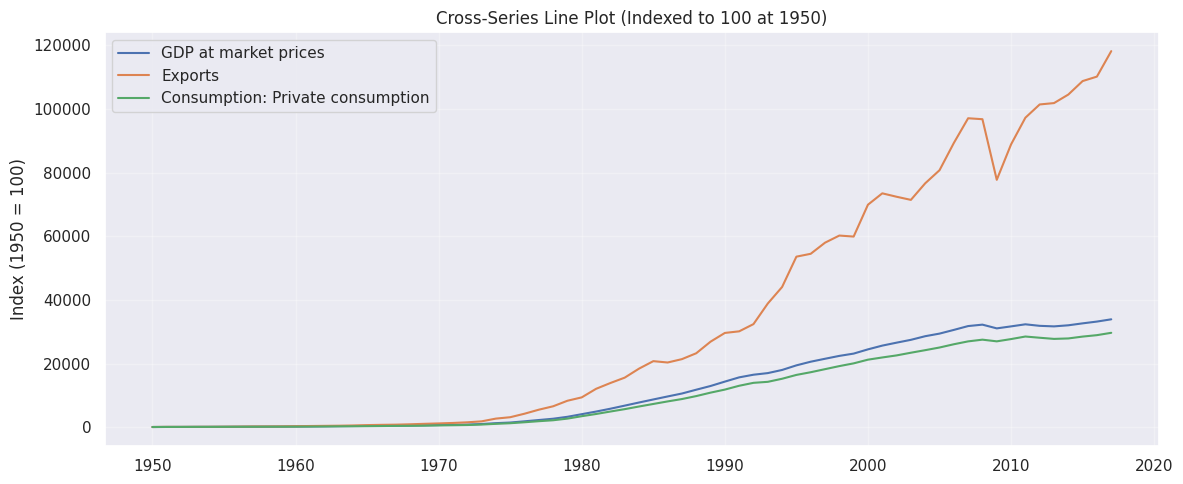

NameError: name 'np' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:

# Select three variables for cross-series analysis
vars_to_plot = ['GDP at market prices', 'Exports', 'Consumption: Private consumption']
data = data[vars_to_plot].copy()

# 1. Line plot (normalised for visibility because scales differ)
fig, ax = plt.subplots(figsize=(12, 5))
for col in data.columns:
    # Normalise to start at 100 for easier comparison of growth rates
    normalized = data[col] / data[col].iloc[0] * 100
    ax.plot(data.index, normalized, label=col)
ax.set_title('Cross-Series Line Plot (Indexed to 100 at 1950)')
ax.set_ylabel('Index (1950 = 100)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Scatter plot with time as colour (GDP vs Exports)
plt.figure(figsize=(8, 6))
sc = plt.scatter(data['Exports'], data['GDP at market prices'],
                 c=np.arange(len(data)), cmap='viridis', alpha=0.8)
plt.colorbar(sc, label='Year (0=1950 → end)')
plt.xlabel('Exports')
plt.ylabel('GDP at market prices')
plt.title('Scatter: GDP vs Exports (colour = time)')
plt.grid(alpha=0.3)
plt.show()

# 3. Lagged scatter plot: Exports at t+2 vs GDP at t
lag = 2
gdp_lagged = data['GDP at market prices'].shift(-lag).dropna()
exports_aligned = data['Exports'].loc[gdp_lagged.index]
plt.figure(figsize=(8, 6))
plt.scatter(exports_aligned, gdp_lagged, alpha=0.6)
plt.xlabel(f'Exports at year t+{lag}')
plt.ylabel(f'GDP at year t')
plt.title(f'Lagged Scatter: GDP(t) vs Exports(t+{lag})')
plt.grid(alpha=0.3)
plt.show()

# 4. Cross-correlation function (Exports -> GDP)
# Make series stationary by first differencing to avoid spurious correlation
gdp_diff = data['GDP at market prices'].diff().dropna()
exports_diff = data['Exports'].diff().dropna()
# Align lengths
min_len = min(len(gdp_diff), len(exports_diff))
gdp_diff_aligned = gdp_diff.iloc[-min_len:]
exports_diff_aligned = exports_diff.iloc[-min_len:]

ccf_vals = ccf(gdp_diff_aligned, exports_diff_aligned)[:10]  # lags 0..9
lags = np.arange(0, 10)
plt.figure(figsize=(8, 4))
plt.bar(lags, ccf_vals)
plt.title('Cross-Correlation Function (GDP first difference vs Exports first difference)')
plt.xlabel('Lag (years)')
plt.ylabel('Correlation')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
cols_to_transform = ['GDP at market prices', 'Exports', 'Total Value Added',
                     'Consumption: Private consumption']
df_trans = data.copy()
lambdas = {}

for col in cols_to_transform:
    y = data[col].values
    y_trans, lam = boxcox(y)
    df_trans[col] = y_trans
    lambdas[col] = lam

KeyError: 'Total Value Added'

In [ ]:
data['GDP at market prices'], lam = boxcox(data['GDP at market prices'])
data_diff = data.diff().dropna()
data_diff.head()

In [ ]:
fig, ax = plt.subplots(nrows=2, figsize=(10, 8))
sns.lineplot(data=data_diff, y="GDP at market prices", x="Year", ax = ax[0])
sns.lineplot(data=data_diff, y="Exports", x="Year", ax = ax[1])
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = data_diff.corr(numeric_only=True)
plt.figure(figsize=(20, 20))

sns.heatmap(
    corr_matrix,
    annot=True,     # Пишем значения внутри ячеек
    cmap='coolwarm', # Цветовая гамма (синий-белый-красный)
    fmt=".2f",      # Формат чисел (2 знака после запятой)
    vmin=-1, vmax=1 # Фиксируем границы цветов (от -1 до 1)
)


plt.show()

In [ ]:
data_diff_2 = data_diff.diff().dropna()
fig, ax = plt.subplots(nrows=2, figsize=(10, 8))
sns.lineplot(data=data_diff_2, y="GDP at market prices", x="Year", ax = ax[0])
sns.lineplot(data=data_diff_2, y="Net Indirect Taxes", x="Year", ax = ax[1])
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test and print results
def adf_test(series, series_name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- {series_name} ---')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical values: {result[4]}')
    if result[1] <= 0.05:
        print('=> Stationary (reject H0)')
    else:
        print('=> Non-stationary (fail to reject H0)')
    print('')

# Apply to all numeric columns (skip the Year column which is index)
for col in data_diff.columns:
    adf_test(data_diff_2[col], col)

NameError: name 'data_diff' is not defined